In [55]:
# ==================================================
# Configuració del projecte
# ==================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [57]:
# ==================================================
# Imports
# ==================================================

import os
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
# ==================================================
# Configuració del projecte
# ==================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.config import (
    DATA_PROCESSED,
    FIGURES_DIR,
    TABLES_DIR,
)

from src.utils_io import (
    load_csv,
    save_csv,
)

In [61]:
# ==================================================
# Carregar datasets
# ==================================================

print("Carregant datasets...")

df_indicators = load_csv(
    DATA_PROCESSED / "indicators_dataset.csv"
)

df_clusters = load_csv(
    DATA_PROCESSED / "cluster_dataset.csv"
)

print("Dataset indicadors:", df_indicators.shape)
print("Dataset clusters:", df_clusters.shape)

Carregant datasets...
Dataset indicadors: (1898, 27)
Dataset clusters: (1898, 31)


In [63]:
# ==================================================
# Fusionar datasets
# ==================================================

print("\nFusionant datasets...")

cluster_cols = [
    "territori",
    "any",
    "cluster",
    "cluster_label",
    "pc1",
    "pc2",
]

df_model = pd.merge(

    df_indicators,

    df_clusters[cluster_cols],

    on=["territori", "any"],

    how="left",

)

print("Dataset model final:", df_model.shape)


Fusionant datasets...
Dataset model final: (1898, 31)



Generant evolució global...


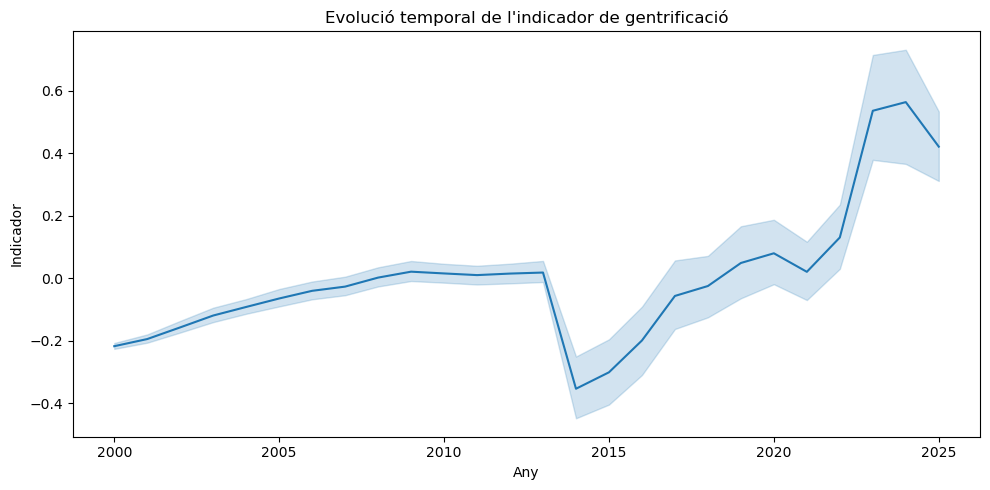

In [65]:
# ==================================================
# Evolució global de la gentrificació
# ==================================================

print("\nGenerant evolució global...")

plt.figure(figsize=(10, 5))

sns.lineplot(

    data=df_model,

    x="any",
    y="indicador_gentrificacio",

)

plt.title(
    "Evolució temporal de l'indicador de gentrificació"
)

plt.xlabel("Any")
plt.ylabel("Indicador")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "evolucio_gentrificacio_global.png",

    dpi=300,
    bbox_inches="tight",

)

plt.show()


Generant evolució per barris...


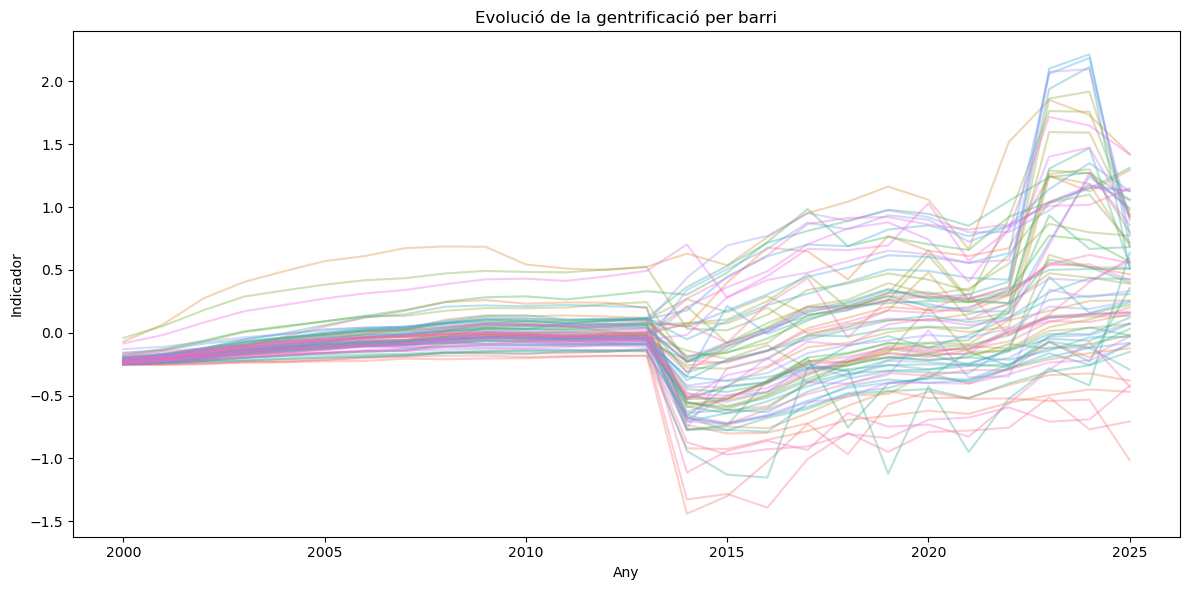

In [66]:
# ==================================================
# Evolució per barris
# ==================================================

print("\nGenerant evolució per barris...")

plt.figure(figsize=(12, 6))

sns.lineplot(

    data=df_model,

    x="any",
    y="indicador_gentrificacio",

    hue="territori",

    legend=False,
    alpha=0.35,

)

plt.title(
    "Evolució de la gentrificació per barri"
)

plt.xlabel("Any")
plt.ylabel("Indicador")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "evolucio_per_barris.png",

    dpi=300,
    bbox_inches="tight",

)

plt.show()

In [69]:
# ==================================================
# Creixement acumulat per barri
# ==================================================

print("\nCalculant creixement acumulat...")

df_growth = (

    df_model
    .sort_values(["territori", "any"])
    .groupby("territori")

    .agg(

        indicador_inicial=(
            "indicador_gentrificacio",
            "first"
        ),

        indicador_final=(
            "indicador_gentrificacio",
            "last"
        ),

    )

    .reset_index()

)

df_growth["creixement"] = (

    df_growth["indicador_final"]
    - df_growth["indicador_inicial"]

)

print(df_growth.head())


Calculant creixement acumulat...
          territori  indicador_inicial  indicador_final  creixement
0     baro de viver          -0.256695        -0.705385   -0.448691
1          can baro          -0.235805         0.168561    0.404366
2       can peguera          -0.246242        -1.013829   -0.767587
3         canyelles          -0.257676        -0.470365   -0.212688
4  ciutat meridiana          -0.249358        -0.381493   -0.132135


In [71]:
# ==================================================
# Classificació de barris
# ==================================================

print("\nClassificant barris...")

q25 = df_growth["creixement"].quantile(0.25)
q50 = df_growth["creixement"].quantile(0.50)
q75 = df_growth["creixement"].quantile(0.75)

def classify_growth(value):

    if value < q25:
        return "Desgentrificació"

    elif value < q50:
        return "Estable"

    elif value < q75:
        return "Gentrificació moderada"

    else:
        return "Gentrificació intensa"

df_growth["categoria_gentrificacio"] = (

    df_growth["creixement"]
    .apply(classify_growth)

)

print("\nDistribució de categories:")

print(
    df_growth["categoria_gentrificacio"]
    .value_counts()
)


Classificant barris...

Distribució de categories:
categoria_gentrificacio
Gentrificació intensa     19
Desgentrificació          18
Estable                   18
Gentrificació moderada    18
Name: count, dtype: int64


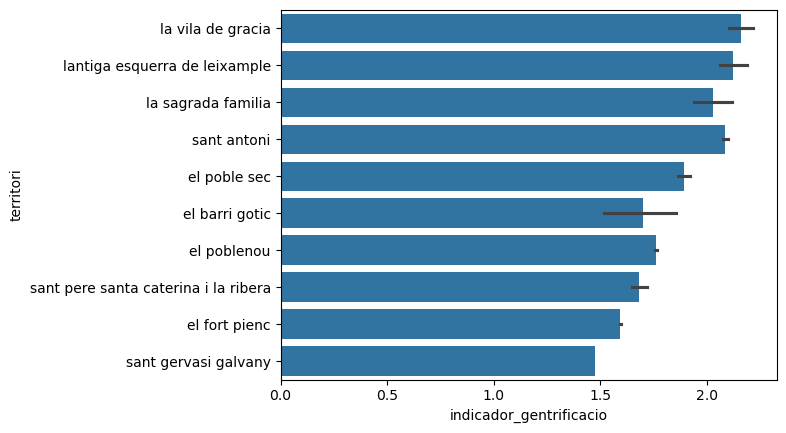

In [85]:
# ==================================================
# Top 10 de barris
# ==================================================

top_barrios = df_model.sort_values(
    'indicador_gentrificacio',
    ascending=False
).head(20)

sns.barplot(
    data=top_barrios,
    y='territori',
    x='indicador_gentrificacio'
)

plt.savefig(

    FIGURES_DIR / "top_10_barris.png",

    dpi=300,
    bbox_inches="tight",

)

In [44]:
# ==================================================
# Afegir classificació al dataset principal
# ==================================================

df_model = pd.merge(

    df_model,

    df_growth[
        [
            "territori",
            "creixement",
            "categoria_gentrificacio",
        ]
    ],

    on="territori",

    how="left",

)


Generant boxplot per categories...


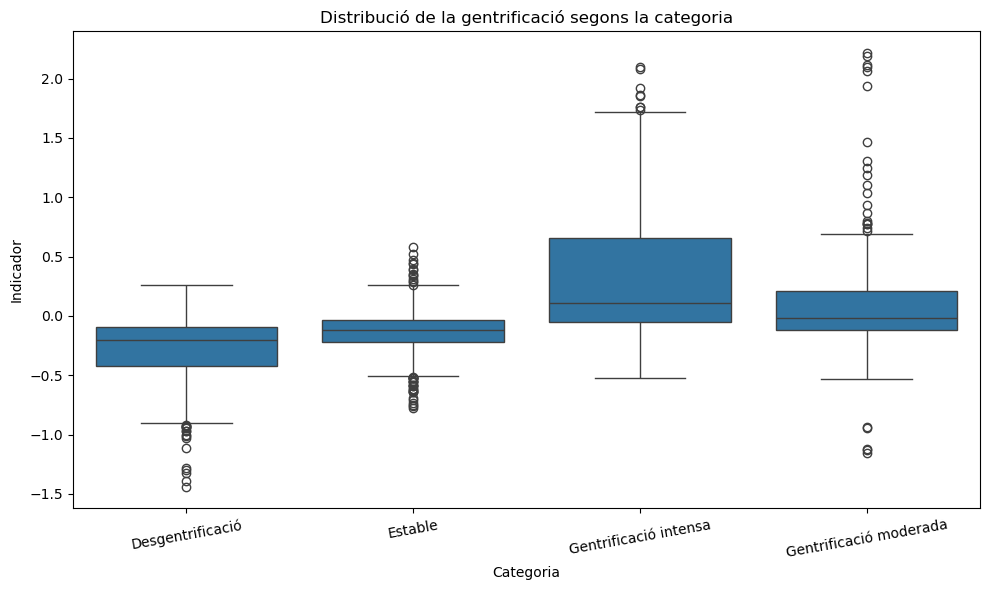

In [49]:
# ==================================================
# Visualització categories
# ==================================================

print("\nGenerant boxplot per categories...")

plt.figure(figsize=(10, 6))

sns.boxplot(

    data=df_model,

    x="categoria_gentrificacio",

    y="indicador_gentrificacio",

)

plt.title(
    "Distribució de la gentrificació segons la categoria"
)

plt.xlabel("Categoria")
plt.ylabel("Indicador")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "boxplot_categories.png",

    dpi=300,
    bbox_inches="tight",

)

plt.show()


Generant evolució per clúster...


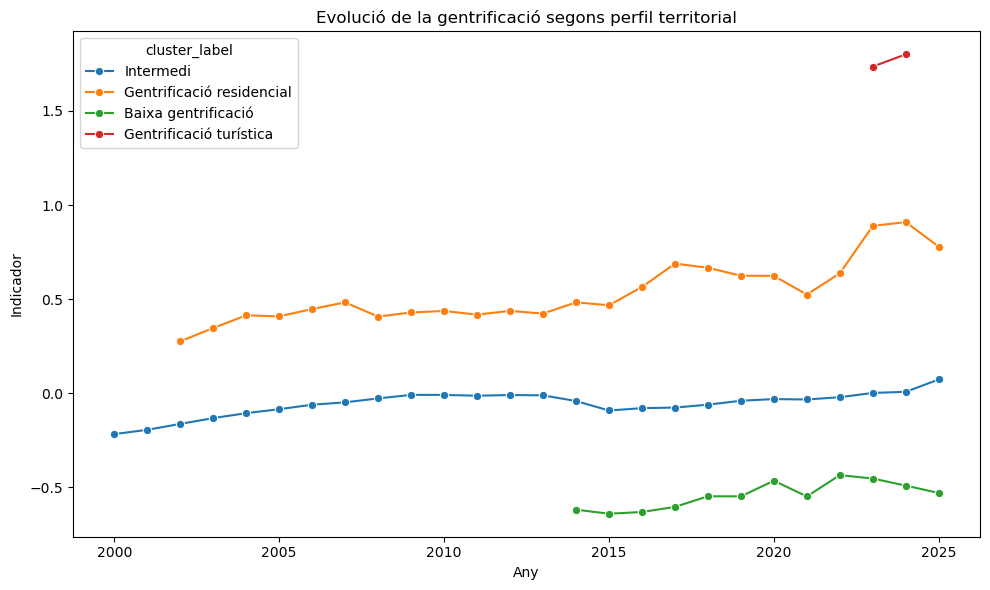

In [50]:
# ==================================================
# Evolució per perfil de clúster
# ==================================================

print("\nGenerant evolució per clúster...")

cluster_evolution = (

    df_model
    .groupby(["any", "cluster_label"])

    ["indicador_gentrificacio"]

    .mean()

    .reset_index()

)

plt.figure(figsize=(10, 6))

sns.lineplot(

    data=cluster_evolution,

    x="any",
    y="indicador_gentrificacio",

    hue="cluster_label",

    marker="o",

)

plt.title(
    "Evolució de la gentrificació segons perfil territorial"
)

plt.xlabel("Any")
plt.ylabel("Indicador")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR / "evolucio_clusters.png",

    dpi=300,
    bbox_inches="tight",

)

plt.show()

In [52]:
# ==================================================
# Exportar dataset final
# ==================================================

print("\nExportant dataset final...")

save_csv(

    df_model,

    DATA_PROCESSED / "modeling_dataset.csv"

)

print("\nNotebook 07_modeling completat correctament.")


Exportant dataset final...

Notebook 07_modeling completat correctament.
